In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [22]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4


In [23]:
df.shape

(4000, 28)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [25]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


DATA CLEANING

In [26]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

We have null values in Rainfall_mm,Soil_Moisture_pct and Yield_Tonnes_Ha

In [27]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [28]:
df.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

UNDERSTANDING THE SEASONS

In [29]:
df["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

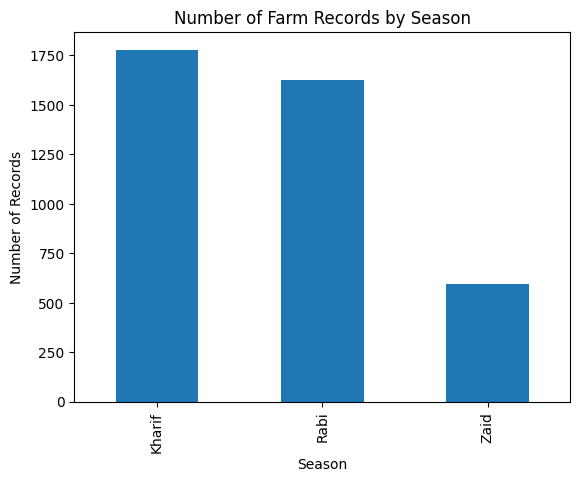

In [56]:
df["Season"].value_counts().plot(kind="bar")

plt.title("Number of Farm Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.savefig("charts/seasons.png")
plt.show()

In [31]:
season_summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
})

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.628612,46.311192,710719.055649,531804.408094,178914.647555,6102.201237,5.891834,54.467903
Rabi,5.039435,41.486712,601526.048556,513836.578365,87689.470191,5846.987093,5.186122,40.482114
Zaid,4.641313,38.886111,519171.904040,543976.728956,-24804.824916,6419.893939,4.413239,38.216667


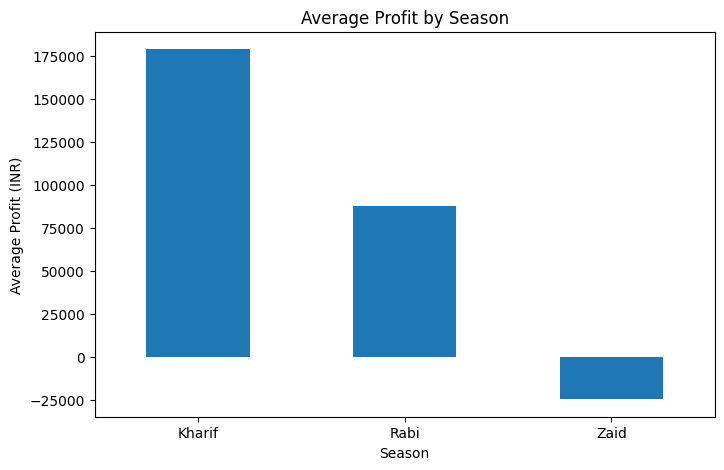

In [57]:
plt.figure(figsize=(8,5))

df.groupby("Season")["Profit_INR"].mean().plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.savefig("charts/Profit by Season.png")
plt.show()

Kharif performs the strongest economically, with average profit around ₹1.79 lakh.

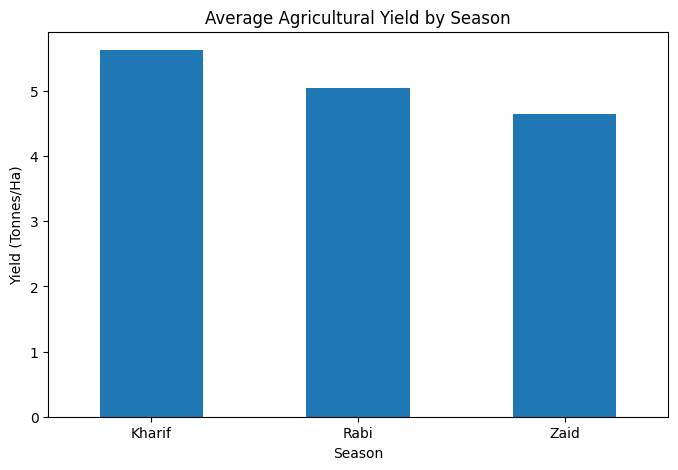

In [58]:
plt.figure(figsize=(8,5))

df.groupby("Season")["Yield_Tonnes_Ha"].mean().plot(kind="bar")

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.savefig("charts/Agricultural Yield by Season.png")
plt.show()


Kharif shows the highest average yield in the dataset; however, the overall seasonal difference in yield is not statistically significant.

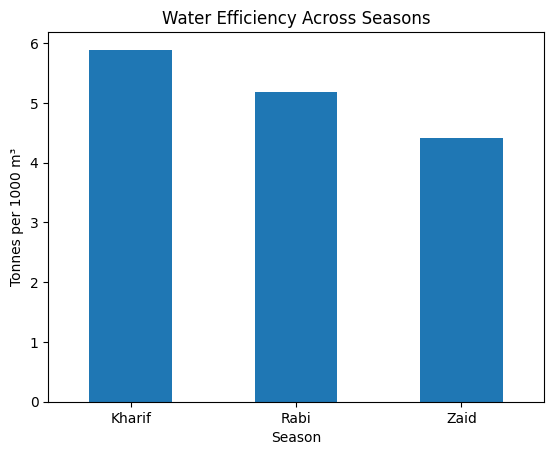

In [59]:
water = df.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean()

water.plot(kind="bar")

plt.title("Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.xticks(rotation=0)
plt.savefig("charts/Water efficiency across seasons.png")
plt.show()


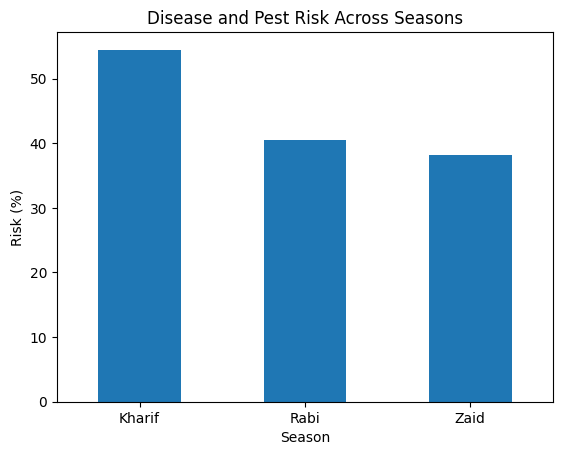

In [65]:
risk = df.groupby("Season")[
    "Disease_Pest_Risk_pct"
].mean()

risk.plot(kind="bar")

plt.title("Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)
plt.savefig("charts/Disease and Pest Risk Across Seasons.png")
plt.show()


In [36]:
crop_season = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


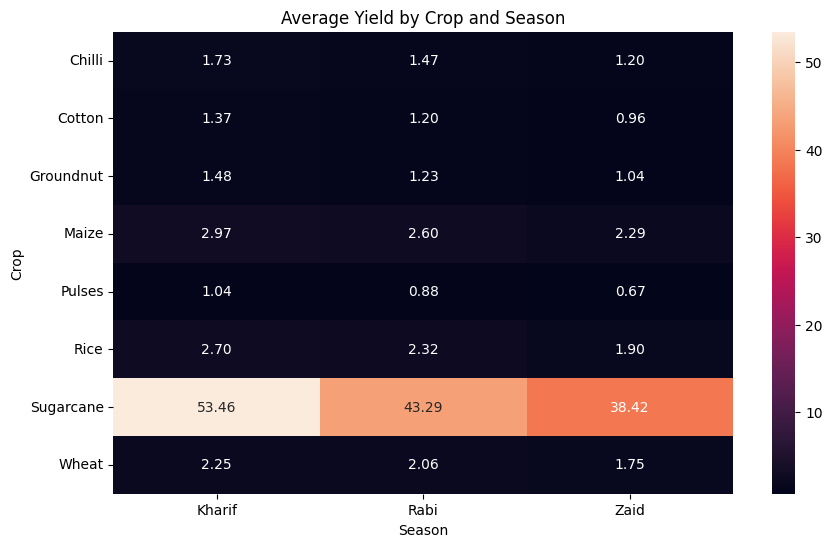

In [60]:
plt.figure(figsize=(10,6))

sns.heatmap(crop_season, annot=True, fmt=".2f")

plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.savefig("charts/Average Yield by Crop and Season.png")
plt.show()


Sugarcane has substantially higher yield levels than the other crops across seasons.

In [39]:
irrigation = df.groupby(
    ["Season", "Irrigation_Method"]
)["Water_Efficiency_t_per_1000m3"].mean().unstack()

irrigation

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,6.803817,3.637156,8.847592,4.622022
Rabi,6.047157,3.477690,6.872941,4.644232
Zaid,5.295921,2.730469,5.479400,4.860067


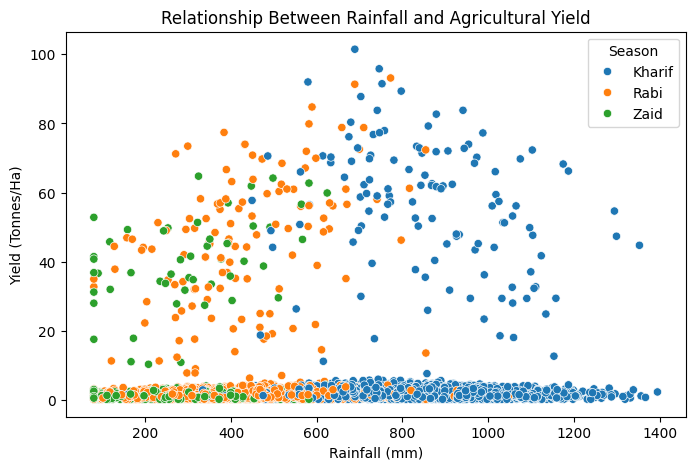

In [61]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Relationship Between Rainfall and Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.savefig("charts/Relationship Between Rainfall and Agricultural Yield.png")
plt.show()

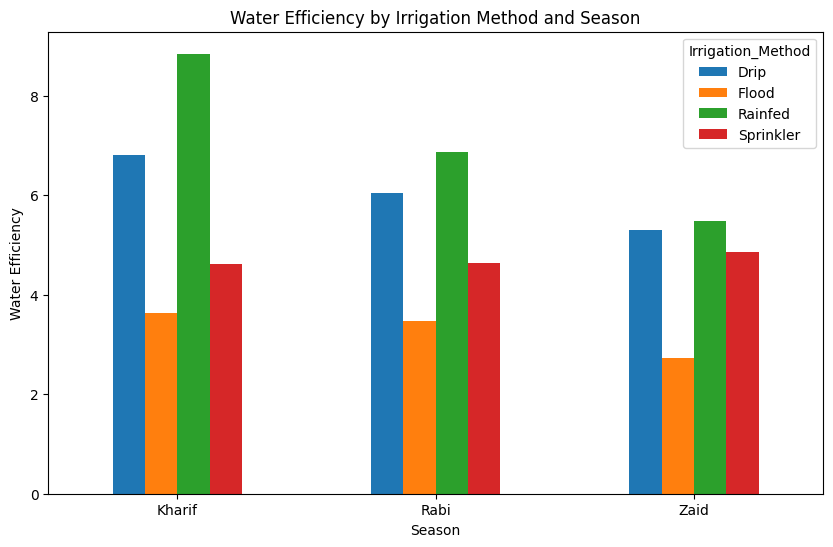

In [64]:
irrigation.plot(kind="bar", figsize=(10,6))

plt.title("Water Efficiency by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")
plt.xticks(rotation=0)
plt.savefig("charts/Water Efficiency by Irrigation Method and Season.png")
plt.show()

In [48]:
df[[
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Avg_Temperature_C",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]].corr()

,Rainfall_mm,Soil_Moisture_pct,Avg_Temperature_C,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.000000,0.508941,0.198492,0.030951,0.107648
Soil_Moisture_pct,0.508941,1.000000,0.084001,0.010999,0.091281
Avg_Temperature_C,0.198492,0.084001,1.000000,0.009996,0.009043
Yield_Tonnes_Ha,0.030951,0.010999,0.009996,1.000000,0.488466
Profit_INR,0.107648,0.091281,0.009043,0.488466,1.000000


In [49]:
state_season_profit = pd.pivot_table(
    df,
    values="Profit_INR",
    index="State",
    columns="Season",
    aggfunc="mean"
)

state_season_profit

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.520833,26315.710784,-84084.870588
Gujarat,217051.330317,82846.195000,-106929.611940
Karnataka,201226.205742,70952.611650,23310.905405
Madhya Pradesh,134242.398230,61576.264423,209.698413
Maharashtra,168801.049550,159581.504587,-40597.597222
Punjab,133779.099548,169294.521505,62109.688312
Tamil Nadu,211303.956311,70456.860577,-15175.197183
Telangana,199668.380342,62824.604061,-34620.776471


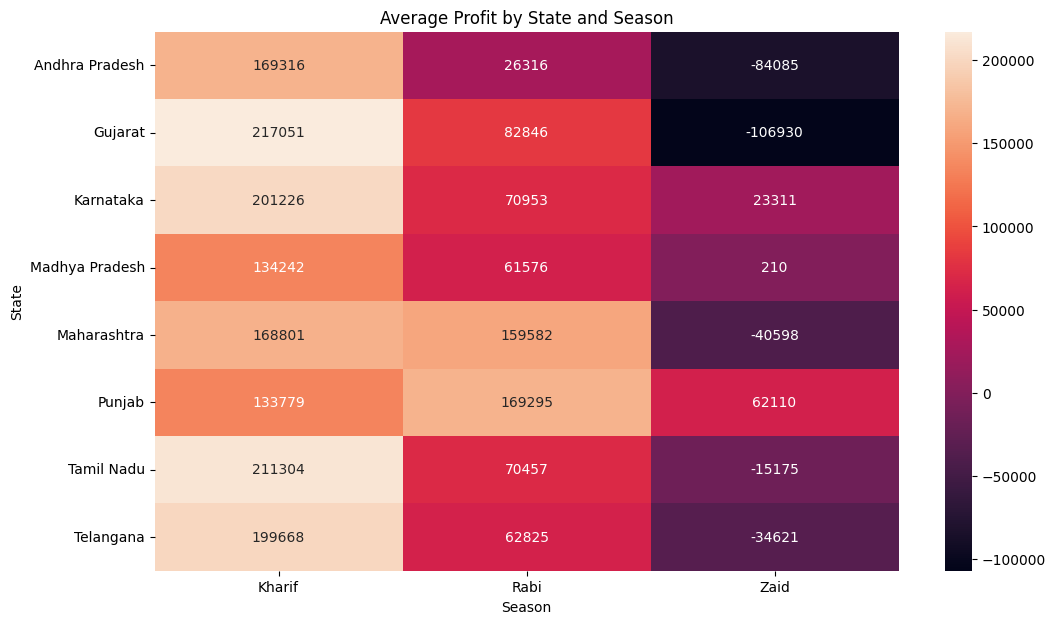

In [62]:
plt.figure(figsize=(12,7))

sns.heatmap(
    state_season_profit,
    annot=True,
    fmt=".0f"
)

plt.title("Average Profit by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.savefig("charts/Average Profit by State and Season.png")
plt.show()

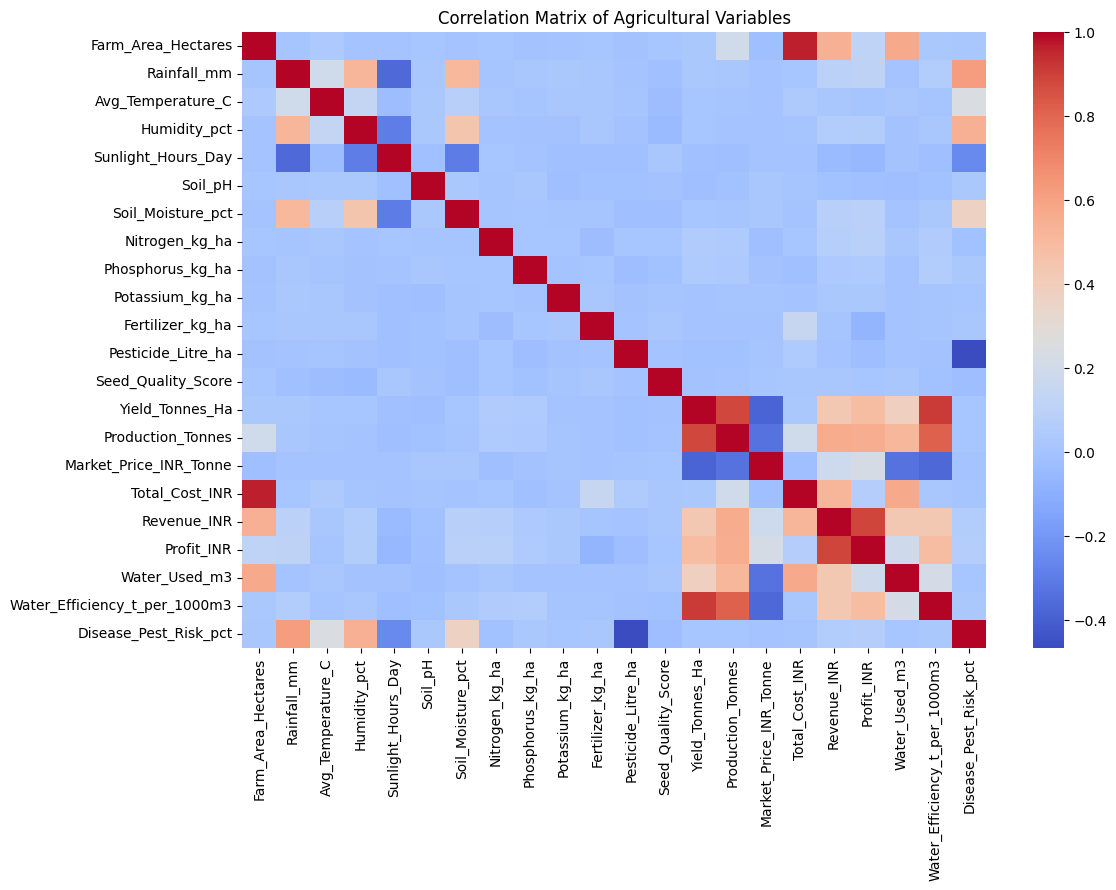

In [63]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Agricultural Variables")
plt.savefig("charts/Correlation Matrix of Agricultural Variables.png")
plt.show()

In [44]:
df.corr(numeric_only=True)["Profit_INR"].sort_values(ascending=False)

Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488466
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.107648
Soil_Moisture_pct                0.091281
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64

In [45]:
kharif = df[df["Season"] == "Kharif"]["Profit_INR"]
rabi = df[df["Season"] == "Rabi"]["Profit_INR"]
zaid = df[df["Season"] == "Zaid"]["Profit_INR"]

f_stat, p_value = stats.f_oneway(
    kharif,
    rabi,
    zaid
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 34.29175033935196
P-value: 1.7124156677360182e-15


In [51]:
negative_profit = df[df["Profit_INR"] < 0]

print("Number of farms with negative profit:",
      len(negative_profit))

print("Percentage:",
      len(negative_profit) / len(df) * 100)

Number of farms with negative profit: 1966
Percentage: 49.15


In [52]:
negative_profit.groupby("Season").size()

Season
Kharif    751
Rabi      832
Zaid      383
dtype: int64

In [53]:
negative_profit.groupby("Crop")["Profit_INR"].mean().sort_values()

Crop
Sugarcane   -292350.400000
Rice        -224127.124454
Maize       -219640.957265
Pulses      -218530.012295
Groundnut   -212730.236994
Cotton      -205987.119318
Wheat       -205044.134066
Chilli      -196557.554054
Name: Profit_INR, dtype: float64

In [46]:
if p_value < 0.05:
    print("There is a statistically significant difference in profit across seasons.")
else:
    print("No statistically significant difference was found.")

There is a statistically significant difference in profit across seasons.
